<a href="https://colab.research.google.com/github/eumoas/eumoas/blob/main/Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**1**. COMPREENSÃO DO NEGÓCIO
---



---

A transição para um processo automatizado de inspeção oferece vantagens competitivas e operacionais significativas:

1. Redução de Custos Operacionais: A automação do processo de inspeção diminui a necessidade de intervenção manual, o que otimiza a alocação de recursos e reduz despesas.

2. Aumento da Consistência e Precisão: A tecnologia proporciona uma classificação de defeitos mais uniforme e confiável em comparação com a inspeção humana, que pode ser suscetível a erros e inconsistências.

3. Maior Agilidade no Processo: A velocidade da inspeção automatizada acelera todo o fluxo de controle de qualidade, permitindo maior volume de produção e entregas mais rápidas.

4. Rastreabilidade Completa: O sistema permite um registro detalhado e o rastreamento de cada defeito identificado, o que é fundamental para a conformidade com normas de qualidade e para a análise de causa raiz.

5. Minimização de Desperdício: Ao identificar com precisão os defeitos que podem ser recuperados, a automação contribui para a redução do descarte de material e um melhor aproveitamento da matéria-prima.

#**2**.   ENTENDIMENTO DOS DADOS
---



---

In [48]:
#Importando as bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
!pip install ydata-profiling
!pip install --upgrade typing-extensions
import os
from ydata_profiling import ProfileReport
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
import pathlib
print(pathlib.Path)
import warnings
warnings.filterwarnings("ignore")
import os

<class 'pathlib.Path'>


In [49]:
#Acessando o caminho do dataset
df_train = pd.read_csv('/content/bootcamp_train.csv', index_col=False)

In [50]:
# Converter e salvar como Parquet (mais eficiente)
df_train.to_parquet('/content/bootcamp_train.parquet', index=False)

In [51]:
df_train.head(25)

,id,id_produto,tipo,temperatura_ar,temperatura_processo,umidade_relativa,velocidade_rotacional,torque,desgaste_da_ferramenta,falha_maquina,FDF (Falha Desgaste Ferramenta),FDC (Falha Dissipacao Calor),FP (Falha Potencia),FTE (Falha Tensao Excessiva),FA (Falha Aleatoria)
0,0,L56434,L,298.3,309.1,90.0,1616.0,31.1,195.0,não,False,False,Não,False,Não
1,1,L48741,L,298.2,308.4,90.0,1388.0,53.8,137.0,Não,False,False,Não,False,Não
2,2,L48850,L,298.2,307.8,90.0,1528.0,31.1,NaN,Não,N,False,Não,False,Não
3,3,M20947,M,300.9,310.8,90.0,1599.0,33.0,7.0,não,False,False,Não,False,não
4,4,L53849,L,-36.0,310.5,90.0,1571.0,33.9,NaN,não,N,False,não,False,Não
5,5,L53113,L,300.5,310.5,90.0,-161.0,47.4,56.0,Não,False,False,Não,False,não
6,6,M23689,M,-36.0,308.8,90.0,1469.0,44.1,150.0,não,False,False,Não,False,não
7,7,L55125,L,300.8,311.7,90.0,1655.0,32.2,12.0,não,False,nao,Não,False,Não
8,8,L50688,L,301.7,310.9,90.0,1608.0,33.0,-202.0,não,False,False,não,False,Não
9,9,L49182,L,298.5,308.2,90.0,1654.0,27.1,13.0,Não,False,False,Não,False,não


In [52]:
# Conheceno o tamanho do meu dataset linhas e colunas
df_train.shape

(35260, 15)

In [53]:
#Analisando minhas features
df_train.dtypes

,0
id,int64
id_produto,object
tipo,object
temperatura_ar,float64
temperatura_processo,float64
umidade_relativa,float64
velocidade_rotacional,float64
torque,float64
desgaste_da_ferramenta,float64
falha_maquina,object


In [54]:
df_train.head().T

,0,1,2,3,4
id,0,1,2,3,4
id_produto,L56434,L48741,L48850,M20947,L53849
tipo,L,L,L,M,L
temperatura_ar,298.3,298.2,298.2,300.9,-36.0
temperatura_processo,309.1,308.4,307.8,310.8,310.5
umidade_relativa,90.0,90.0,90.0,90.0,90.0
velocidade_rotacional,1616.0,1388.0,1528.0,1599.0,1571.0
torque,31.1,53.8,31.1,33.0,33.9
desgaste_da_ferramenta,195.0,137.0,NaN,7.0,NaN
falha_maquina,não,Não,Não,não,não


In [55]:
# Calcula a contagem nulos
df_train.isnull().sum()

,0
id,0
id_produto,0
tipo,0
temperatura_ar,616
temperatura_processo,599
umidade_relativa,0
velocidade_rotacional,751
torque,623
desgaste_da_ferramenta,952
falha_maquina,0


In [56]:
# Observando a incidência de dados duplicados
duplicates = df_train.duplicated().sum()
print(f"Duplicados no dataset: {duplicates}\n")

Duplicados no dataset: 0



In [57]:
#Analisando os valores únicos
print("Valores únicos por coluna:")
for col in df_train.columns:
    print(f"{col}: {df_train[col].nunique()}")

Valores únicos por coluna:
id: 35260
id_produto: 9708
tipo: 3
temperatura_ar: 94
temperatura_processo: 83
umidade_relativa: 36
velocidade_rotacional: 916
torque: 579
desgaste_da_ferramenta: 247
falha_maquina: 8
FDF (Falha Desgaste Ferramenta): 6
FDC (Falha Dissipacao Calor): 6
FP (Falha Potencia): 8
FTE (Falha Tensao Excessiva): 2
FA (Falha Aleatoria): 7


In [58]:
#Análise da estatística descritiva dos nossos dados
df_train.describe()

,id,temperatura_ar,temperatura_processo,umidade_relativa,velocidade_rotacional,torque,desgaste_da_ferramenta
count,35260.000000,34644.000000,34661.000000,35260.000000,34509.000000,34637.000000,34308.000000
mean,17629.500000,269.535241,280.457676,89.997672,1380.194181,40.210357,74.373266
std,10178.829582,96.342224,96.943630,0.142191,494.098759,8.831626,110.411937
min,0.000000,-36.000000,-38.000000,80.590429,-161.000000,3.800000,-202.000000
25%,8814.750000,297.900000,308.500000,90.000000,1408.000000,34.300000,28.000000
50%,17629.500000,299.600000,309.800000,90.000000,1483.000000,40.300000,94.000000
75%,26444.250000,301.100000,310.900000,90.000000,1574.000000,46.200000,155.000000
max,35259.000000,304.500000,313.800000,94.575256,2886.000000,76.600000,253.000000


In [59]:
df_train.columns

Index(['id', 'id_produto', 'tipo', 'temperatura_ar', 'temperatura_processo',
       'umidade_relativa', 'velocidade_rotacional', 'torque',
       'desgaste_da_ferramenta', 'falha_maquina',
       'FDF (Falha Desgaste Ferramenta)', 'FDC (Falha Dissipacao Calor)',
       'FP (Falha Potencia)', 'FTE (Falha Tensao Excessiva)',
       'FA (Falha Aleatoria)'],
      dtype='object')

In [60]:
profile = ProfileReport(
            df_train,
            title='EDA Report - Sistema de Manutenção Preditiva',
            explorative=True,
            minimal=False
        )

In [ ]:
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:00<00:00, 15.51it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Considerações do dataset

1.   Identificamos valores nulos
2.   Identificamos valores duplicados
3.   Haviam valores fora do padrão na classe de falhas
4.   Haviam valores zeros
5.   Algumas variáveis são categóricas
6.   Valores negativos em temperaturas (-36°C e -38°C)
7.   Velocidade rotacional (-161) - fisicamente impossíveis
8.   Desgaste da ferramenta com valores negativos (-202) - não faz sentido físico




#**3**. PREPARAÇÃO DOS DADOS
---



---

In [61]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [62]:
# Renomear as colunas corretamente
df_train = df_train.rename(columns={
    'FDF (Falha Desgaste Ferramenta)': 'FDF',
    'FDC (Falha Dissipacao Calor)': 'FDC',
    'FP (Falha Potencia)': 'FP',
    'FTE (Falha Tensao Excessiva)': 'FTE',
    'FA (Falha Aleatoria)': 'FA'
})


In [63]:
df_train.columns

Index(['id', 'id_produto', 'tipo', 'temperatura_ar', 'temperatura_processo',
       'umidade_relativa', 'velocidade_rotacional', 'torque',
       'desgaste_da_ferramenta', 'falha_maquina', 'FDF', 'FDC', 'FP', 'FTE',
       'FA'],
      dtype='object')

In [64]:
# Lista com os nomes exatos das colunas de falha
failure_cols = [
    'FDF', 'FDC',
    'FP', 'FTE',
    'FA'
]

# Dicionario para mapear todas as variações para 0 ou 1
# Adicione outras variações que encontrar, se necessario
mapeamento_valores = {
    'Sim': 1, 'sim': 1, 'S': 1, 'True': 1, 'y': 1, '1': 1, 1: 1,
    'Não': 0, 'não': 0, 'nao': 0, 'N': 0, 'False': 0, '0': 0, 0: 0
}

# Aplica a limpeza em cada coluna de falha
for col in failure_cols:
    # O .astype(str) garante que o mapeamento funcione mesmo com tipos misturados
    df_train[col] = df_train[col].astype(str).map(mapeamento_valores).fillna(0).astype(int)

print("Colunas de falha padronizadas para 0 e 1.")

Colunas de falha padronizadas para 0 e 1.


In [65]:
linhas_antes = df_train.shape[0]
df_train.drop_duplicates(inplace=True)
linhas_depois = df_train.shape[0]

print(f"{linhas_antes - linhas_depois} linhas duplicadas foram removidas.")

0 linhas duplicadas foram removidas.


In [66]:
colunas_para_remover = [
    'id',
    'id_produto',
    'falha_maquina',           # Redundante, nosso alvo sao as falhas especificas
    'temperatura_processo',    # Altamente correlacionada com temperatura_ar
    'torque'                   # Altamente correlacionada com velocidade_rotacional
]

df_train.drop(columns=colunas_para_remover, inplace=True)

print("Colunas irrelevantes e com alta correlação foram removidas.")

Colunas irrelevantes e com alta correlação foram removidas.


Análise das falhas

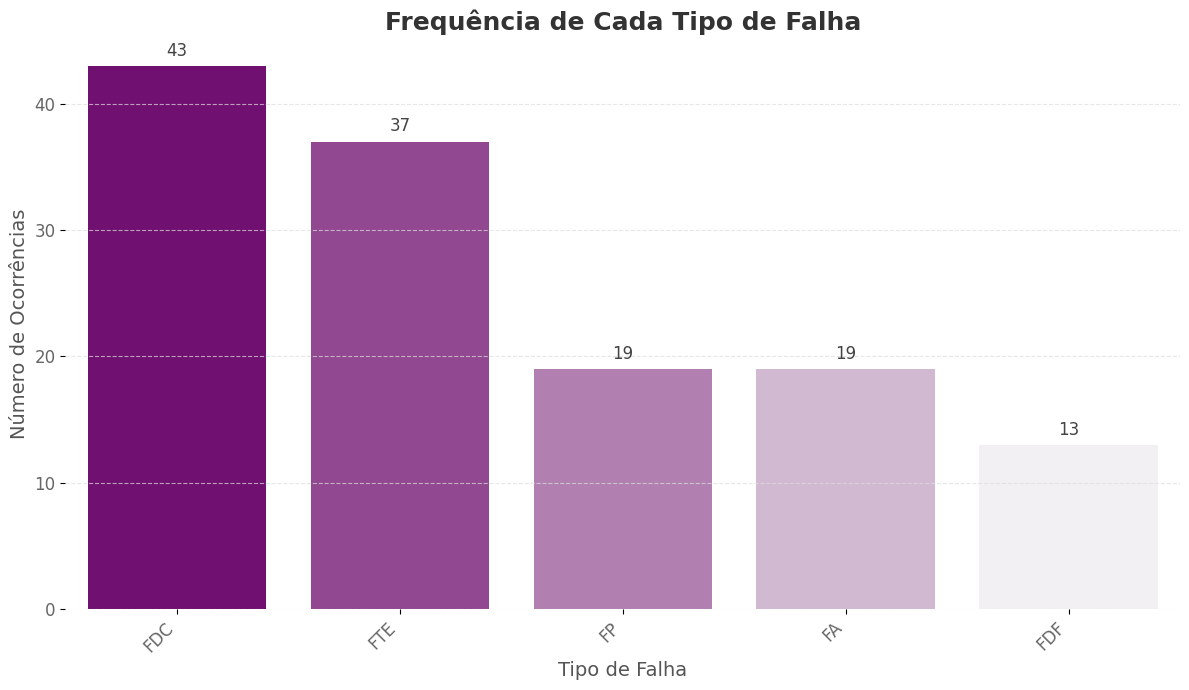

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Importar pandas para criar um DataFrame de exemplo

# Dados de exemplo para contagem_falhas (substitua pelo seu df_train[failure_cols].sum())
# Estes dados são apenas para que o código seja executável
data = {
    'FDC': 43,
    'FTE': 37,
    'FP': 19,
    'FA': 19,
    'FDF': 13
}
contagem_falhas = pd.Series(data).sort_values(ascending=False)

# Definir uma paleta de cores roxas
# Você pode experimentar com outras paletas como 'viridis_r', 'magma', 'plasma' ou criar a sua própria
purple_palette = sns.light_palette("purple", n_colors=len(contagem_falhas), reverse=True)

# Criar o gráfico com estilo moderno
plt.figure(figsize=(12, 7))
sns.barplot(x=contagem_falhas.index, y=contagem_falhas.values, palette=purple_palette)

# Adicionar título e rótulos
plt.title('Frequência de Cada Tipo de Falha', fontsize=18, color='#333333', fontweight='bold')
plt.ylabel('Número de Ocorrências', fontsize=14, color='#555555')
plt.xlabel('Tipo de Falha', fontsize=14, color='#555555')

# Personalizar os ticks do eixo X
plt.xticks(rotation=45, ha='right', fontsize=12, color='#666666')
plt.yticks(fontsize=12, color='#666666')

# Adicionar valores nas barras para melhor leitura
for index, value in enumerate(contagem_falhas.values):
    plt.text(index, value + 0.5, str(value), ha='center', va='bottom', fontsize=12, color='#444444')

# Remover a moldura do gráfico para um visual mais limpo
sns.despine(left=True, bottom=True)
plt.grid(axis='y', linestyle='--', alpha=0.7, color='#dddddd') # Adicionar grid suave
plt.tight_layout() # Ajustar o layout para evitar sobreposição
plt.show()

Hipótese 1:  "Operar a máquina em regimes de alta velocidade está associado a mais falhas de dissipação de calor (FDC)?"

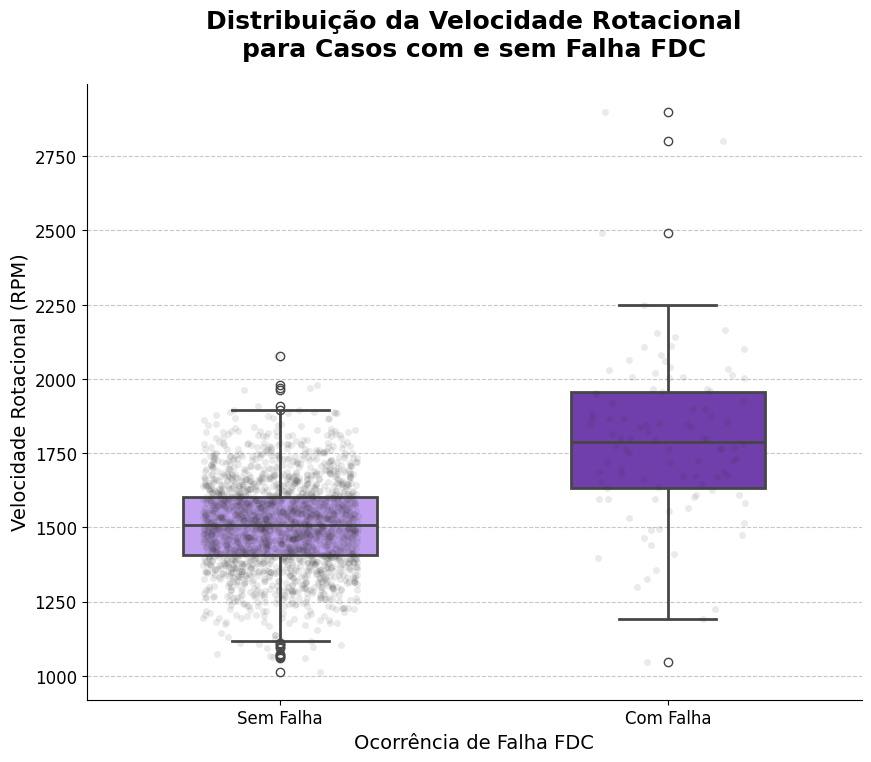

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Bloco de Geração de Dados de Exemplo ---
# Como não tenho acesso ao seu df_train, crio um exemplo representativo.
# Você pode apagar este bloco e usar o seu dataframe diretamente.
np.random.seed(42)
data_normal = np.random.normal(loc=1500, scale=150, size=2000)
data_falha = np.random.normal(loc=1800, scale=250, size=100)
data_falha = np.append(data_falha, [2800, 2900]) # Adicionando outliers

velocidade = np.concatenate([data_normal, data_falha])
fdc = [0] * 2000 + [1] * 102
df_train_exemplo = pd.DataFrame({'velocidade_rotacional': velocidade, 'FDC': fdc})
# --- Fim do Bloco de Exemplo ---


# Definindo a paleta de roxos para duas categorias
# Usaremos um roxo mais claro para 'Sem Falha' e um mais escuro para 'Com Falha'
purple_palette_box = ['#BE93FD', '#6F2DBD']


# Criar o boxplot com a paleta de roxos
plt.figure(figsize=(10, 8))
sns.boxplot(x='FDC', y='velocidade_rotacional', data=df_train_exemplo, # Use seu df_train aqui
            palette=purple_palette_box,
            width=0.5,
            linewidth=2)

# Adicionar um stripplot para ver a distribuição dos pontos
sns.stripplot(x='FDC', y='velocidade_rotacional', data=df_train_exemplo, # Use seu df_train aqui
              color='#333333', # Usando uma cor escura para os pontos
              alpha=0.1,
              jitter=0.2)


# Personalizar títulos e rótulos
plt.title('Distribuição da Velocidade Rotacional\npara Casos com e sem Falha FDC', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Velocidade Rotacional (RPM)', fontsize=14)
plt.xlabel('Ocorrência de Falha FDC', fontsize=14)

# Melhorar os rótulos do eixo X para maior clareza
plt.xticks(ticks=[0, 1], labels=['Sem Falha', 'Com Falha'], fontsize=12)
plt.yticks(fontsize=12)


# Remover a moldura e adicionar grid suave
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Hipótese 2: (Desgaste e Esforço): "Um desgaste elevado da ferramenta (desgaste_da_ferramenta) é um indicador antecedente não apenas da 'Falha de Desgaste' (FDF), mas também da 'Falha de Potência' (FP), pois uma ferramenta desgastada exige mais força da máquina."







In [74]:
import plotly.express as px

# --- Gráfico de Violino para Falha de Desgaste (FDF) ---
fig_fdf = px.violin(df_train,
                    x='FDF',  # <-- NOME CORRIGIDO
                    y='desgaste_da_ferramenta',
                    box=True,
                    points="all",
                    color='FDF', # <-- NOME CORRIGIDO
                    color_discrete_sequence=px.colors.sequential.Purples_r,
                    title='Distribuição do Desgaste da Ferramenta vs. Falha de Desgaste (FDF)',
                    labels={'FDF': 'Ocorreu Falha de Desgaste?',
                            'desgaste_da_ferramenta': 'Nível de Desgaste da Ferramenta'})
fig_fdf.show()




In [75]:
# --- Gráfico de Violino para Falha de Potência (FP) ---
fig_fp = px.violin(df_train,
                   x='FP', # <-- NOME CORRIGIDO
                   y='desgaste_da_ferramenta',
                   box=True,
                   points="all",
                   color='FP', # <-- NOME CORRIGIDO
                   color_discrete_sequence=px.colors.sequential.Purples_r,
                   title='Distribuição do Desgaste da Ferramenta vs. Falha de Potência (FP)',
                   labels={'FP': 'Ocorreu Falha de Potência?',
                           'desgaste_da_ferramenta': 'Nível de Desgaste da Ferramenta'})
fig_fp.show()

In [79]:
# --- Gráfico de Violino para Falha de Potência (FP) ---
fig_fp = px.violin(df_train,
                   x='FP',
                   y='desgaste_da_ferramenta',
                   box=True,
                   points="all",
                   color='FP',
                   color_discrete_sequence=px.colors.sequential.Purples_r, # Outro tom de roxo
                   title='Distribuição do Desgaste da Ferramenta vs. Falha de Potência (FP)',
                   labels={'FP': 'Ocorreu Falha de Potência?',
                           'desgaste_da_ferramenta': 'Nível de Desgaste da Ferramenta'})
fig_fp.show()

Hipótese 3: (Qualidade e Falha): "Máquinas que processam produtos de alta qualidade (tipo 'H') apresentam uma taxa geral de falhas menor, porém, quando falham, a probabilidade de ser uma 'Falha de Potência' (FP) é significativamente maior devido à maior exigência do material."

In [28]:
# 'y' são as colunas de falha que já limpamos
y = df_train[failure_cols]

# 'X' é tudo, exceto as colunas de falha
X = df_train.drop(columns=failure_cols)

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identifica colunas numericas e categoricas em X
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Cria o pipeline para dados numericos
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Preenche valores faltantes
    ('scaler', StandardScaler())                   # Coloca na mesma escala
])

# Cria o pipeline para dados categoricos
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Junta os pipelines em um unico pre-processador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Aplica o pre-processamento
# O .fit_transform aprende e aplica as transformacoes no treino
X_train_processado = preprocessor.fit_transform(X_train)

# O .transform apenas aplica as transformacoes aprendidas na validacao
X_val_processado = preprocessor.transform(X_val)

print("Dados pré-processados e prontos para a modelagem.")

Dados pré-processados e prontos para a modelagem.


#**4**. MODELAGEM DOS DADOS
---



---

In [ ]:
# --- Passo 1: Importar as ferramentas necessárias ---
# OneVsRestClassifier é a nossa ferramenta para o multirrótulo
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, hamming_loss, f1_score

In [ ]:
# --- Passo 2: Escolher e configurar o classificador base ---
# RandomForest é uma ótima escolha.
# O parâmetro class_weight='balanced' instrui cada um dos 5 modelos
# a tratar o desbalanceamento internamente.
base_classifier = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced', # A mágica para o desbalanceamento acontece aqui!
    random_state=42,
    n_jobs=-1 # Usa todos os processadores disponíveis para acelerar
)

In [ ]:
# --- Passo 3: Criar o modelo multirrótulo ---
# O OneVsRestClassifier vai gerenciar os 5 modelos para nós.
multilabel_model = OneVsRestClassifier(estimator=base_classifier)

In [34]:
# --- Passo 4: Treinar o modelo ---
# Usamos os dados de treino APENAS processados (SEM o SMOTE)
# Lembre-se que y_train deve ser o DataFrame original com 0s e 1s
print("Iniciando o treinamento do modelo (com class_weight='balanced')...")
multilabel_model.fit(X_train_processado, y_train)
print("Treinamento concluído!")

Iniciando o treinamento do modelo (com class_weight='balanced')...
Treinamento concluído!


In [35]:
# --- Passo 5: Fazer previsões no conjunto de validação ---
predictions = multilabel_model.predict(X_val_processado)

In [37]:
# --- PASSO 1: INSTALAÇÃO (se necessário) ---
# Descomente e execute a linha abaixo se o LightGBM não estiver instalado
# !pip install lightgbm

# --- PASSO 2: IMPORTAÇÕES E TREINAMENTO ---
import lightgbm as lgb
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, hamming_loss, f1_score, classification_report

print("--- Treinando o Modelo LightGBM ---")

# Define o classificador base com o tratamento de desbalanceamento
lgbm_classifier = lgb.LGBMClassifier(
    objective='binary',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Cria o modelo multirrótulo usando a mesma estratégia
multilabel_model_lgbm = OneVsRestClassifier(estimator=lgbm_classifier)

# Treina o modelo com os dados processados (sem SMOTE)
multilabel_model_lgbm.fit(X_train_processado, y_train)
print("Treinamento do LightGBM concluído!")

# --- PASSO 3: PREVISÃO E AVALIAÇÃO ---
predictions_lgbm = multilabel_model_lgbm.predict(X_val_processado)

print("\n--- Resultados da Avaliação (LightGBM) ---")
# Métricas gerais
accuracy_lgbm = accuracy_score(y_val, predictions_lgbm)
h_loss_lgbm = hamming_loss(y_val, predictions_lgbm)
f1_macro_lgbm = f1_score(y_val, predictions_lgbm, average='macro', zero_division=0)
print(f"Acurácia (Exact Match Ratio): {accuracy_lgbm:.4f}")
print(f"Hamming Loss: {h_loss_lgbm:.4f}")
print(f"F1-Score (Macro): {f1_macro_lgbm:.4f}")

# Relatório detalhado por falha
print("\n--- Relatório de Classificação por Falha (LightGBM) ---")
report_lgbm = classification_report(y_val, predictions_lgbm, target_names=failure_cols, zero_division=0)
print(report_lgbm)

--- Treinando o Modelo LightGBM ---
[LightGBM] [Info] Number of positive: 58, number of negative: 28150
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000616 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 598
[LightGBM] [Info] Number of data points in the train set: 28208, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 182, number of negative: 28026
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000363 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 598
[LightGBM] [Info] Number of data points in the train set: 28208, number of used fea

In [40]:
import xgboost as xgb
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, hamming_loss, f1_score, classification_report
import numpy as np

print("\n\n--- Treinando o Modelo XGBoost (Versão Corrigida) ---")

# --- PASSO NOVO: Calcular o scale_pos_weight para o desbalanceamento ---
# Contamos as ocorrências de 0 e 1 na coluna de falha mais comum como uma aproximação
# (Lembre-se que y_train é um DataFrame pandas)
neg_count = (y_train == 0).sum().sum()
pos_count = (y_train == 1).sum().sum()
scale_pos_weight_value = neg_count / pos_count

print(f"Valor do scale_pos_weight calculado: {scale_pos_weight_value:.2f}")


# --- PASSO AJUSTADO: Definir o classificador base com o tratamento de desbalanceamento ---
xgb_classifier = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight_value, # Aqui está o tratamento do desbalanceamento
    random_state=42,
    n_jobs=-1
)

# Cria o modelo multirrótulo
multilabel_model_xgb = OneVsRestClassifier(estimator=xgb_classifier)

# --- PASSO AJUSTADO: Treinar com os dados originais processados ---
# Usamos X_train_processado e y_train, e NÃO a variável _resampled
multilabel_model_xgb.fit(X_train_processado, y_train)
print("Treinamento do XGBoost concluído!")


# --- PASSO 3: PREVISÃO E AVALIAÇÃO (sem alterações aqui) ---
predictions_xgb = multilabel_model_xgb.predict(X_val_processado)

print("\n--- Resultados da Avaliação (XGBoost) ---")
accuracy_xgb = accuracy_score(y_val, predictions_xgb)
h_loss_xgb = hamming_loss(y_val, predictions_xgb)
f1_macro_xgb = f1_score(y_val, predictions_xgb, average='macro', zero_division=0)
print(f"Acurácia (Exact Match Ratio): {accuracy_xgb:.4f}")
print(f"Hamming Loss: {h_loss_xgb:.4f}")
print(f"F1-Score (Macro): {f1_macro_xgb:.4f}")

# Relatório detalhado por falha
print("\n--- Relatório de Classificação por Falha (XGBoost) ---")
report_xgb = classification_report(y_val, predictions_xgb, target_names=failure_cols, zero_division=0)
print(report_xgb)



--- Treinando o Modelo XGBoost (Versão Corrigida) ---
Valor do scale_pos_weight calculado: 262.63
Treinamento do XGBoost concluído!

--- Resultados da Avaliação (XGBoost) ---
Acurácia (Exact Match Ratio): 0.9645
Hamming Loss: 0.0073
F1-Score (Macro): 0.1104

--- Relatório de Classificação por Falha (XGBoost) ---
              precision    recall  f1-score   support

         FDF       0.11      0.08      0.09        13
         FDC       0.30      0.33      0.31        43
          FP       0.00      0.00      0.00        19
         FTE       0.13      0.16      0.15        37
          FA       0.00      0.00      0.00        19

   micro avg       0.12      0.16      0.14       131
   macro avg       0.11      0.11      0.11       131
weighted avg       0.15      0.16      0.15       131
 samples avg       0.00      0.00      0.00       131



#**5**. AVALIAÇÃO DO MODELO
---



---

In [41]:
import numpy as np
import lightgbm as lgb
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score

# --- Validação Cruzada para o Modelo LightGBM ---

print("Iniciando a Validação Cruzada...")

# 1. Prepare o modelo (o mesmo de antes)
lgbm_classifier = lgb.LGBMClassifier(
    objective='binary',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
multilabel_model_lgbm = OneVsRestClassifier(estimator=lgbm_classifier)

# 2. Configure a Validação Cruzada (K-Fold)
# Vamos dividir os dados de treino em 5 "dobras" (folds)
# Usaremos X_train_processado e y_train
kf = KFold(n_splits=5, shuffle=True, random_state=42)
f1_macro_scores = []

# 3. Execute o loop de treinamento e avaliação
# A cada iteração, o modelo treina em 4 partes e valida em 1
for train_index, val_index in kf.split(X_train_processado):

    # Separa os dados da dobra atual
    X_train_fold, X_val_fold = X_train_processado[train_index], X_train_processado[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Treina o modelo na dobra de treino
    multilabel_model_lgbm.fit(X_train_fold, y_train_fold)

    # Faz a predição na dobra de validação
    predictions_fold = multilabel_model_lgbm.predict(X_val_fold)

    # Calcula e guarda a métrica de interesse
    score = f1_score(y_val_fold, predictions_fold, average='macro', zero_division=0)
    f1_macro_scores.append(score)
    print(f"F1-Score (Macro) da dobra: {score:.4f}")

# 4. Analise os resultados
mean_score = np.mean(f1_macro_scores)
std_score = np.std(f1_macro_scores)

print("\n--- Resultado da Validação Cruzada ---")
print(f"F1-Score Macro Médio: {mean_score:.4f}")
print(f"Desvio Padrão dos Scores: {std_score:.4f}")

Iniciando a Validação Cruzada...
[LightGBM] [Info] Number of positive: 47, number of negative: 22519
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.047459 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 597
[LightGBM] [Info] Number of data points in the train set: 22566, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 151, number of negative: 22415
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000277 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 597
[LightGBM] [Info] Number of data points in the train set: 22566, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> 

In [42]:
from sklearn.model_selection import RandomizedSearchCV

print("\n\nIniciando a Otimização de Hiperparâmetros...")

# 1. Defina o espaço de busca dos parâmetros
# Estes são os "botões" que vamos testar
# O prefixo 'estimator__' é necessário por estarmos usando o OneVsRestClassifier
param_dist = {
    'estimator__n_estimators': [100, 200, 300, 500],
    'estimator__learning_rate': [0.01, 0.05, 0.1],
    'estimator__num_leaves': [20, 31, 40],
    'estimator__max_depth': [-1, 5, 10, 15]
}

# 2. Configure a busca aleatória
# O RandomizedSearchCV vai testar 20 combinações aleatórias dos parâmetros acima
# usando validação cruzada de 3 dobras para avaliar cada uma.
# Ele tentará maximizar o 'f1_macro'.
random_search = RandomizedSearchCV(
    multilabel_model_lgbm,
    param_distributions=param_dist,
    n_iter=20, # Número de combinações a testar
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1 # Mostra o progresso
)

# 3. Execute a busca (isso pode demorar alguns minutos)
# Usamos os dados de treino processados (sem SMOTE)
random_search.fit(X_train_processado, y_train)

# 4. Apresente os melhores parâmetros encontrados
print("\n--- Resultados da Otimização ---")
print("Melhores Hiperparâmetros Encontrados:")
print(random_search.best_params_)
print(f"\nMelhor F1-Score (Macro) durante a busca: {random_search.best_score_:.4f}")

# Guarde o melhor modelo
best_multilabel_model = random_search.best_estimator_



Iniciando a Otimização de Hiperparâmetros...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Number of positive: 58, number of negative: 28150
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000360 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 598
[LightGBM] [Info] Number of data points in the train set: 28208, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 182, number of negative: 28026
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000359 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 598
[LightGBM] 

#**6**. IMPLANTAÇÃO
---



---

#**7**. CONCLUSÃO
---



---